In [1]:
import numpy as np
from importlib import reload
import matplotlib.pyplot as plt
import sys
from pathlib import Path
%matplotlib widget

In [2]:
module_path = Path('..').resolve()
if str(module_path) not in sys.path:
    sys.path.insert(0, str(module_path))
import custom_prospector_tools as cpt
cpt = reload(cpt)

First we read SPHEREx filters.  
The central wavelength has to be read in too since there are some weird bandpass outside major throughput regions and can cause the effective wavelength to be off center.
Use `read_filters` function to read them as uniformr numpy array

In [3]:
filter_list = '/Users/brianwang76/SPHEREx/SPHEREx-L4-Redshift-Pipeline/redshifts/data/FILTER/SPHEREx_306/fiducial_filters.txt'
filters, lamb_obs = cpt.read_filters(filter_list, return_lamb_obs=True)
# filter_central_wavelengths = filter_list.replace('fiducial_filters.txt', 'fiducial_filters_cent_waves.txt')
# central_wavelengths_tab = np.loadtxt(filter_central_wavelengths, dtype={'names': ('filter','wavelengths'), 'formats': ('U25','f8')})
# lamb_obs = central_wavelengths_tab['wavelengths']

Create a custom prospector object with `cpt.custom_prospector`.  
When creating the object, we need to specify the SFH model we want, since it determines the SSPBasis from FSPS.  
There is an optional keyword, `filters`, that we can load either the numpy array from above, or a list of `Sedpy` objects.

Noted this only has to be done ONCE, but if you want a different SFH model, you need to create a separate object

In [4]:
pros_obj = cpt.custom_prospector(sfh_type='continuity_sfh', filters=filters)

When creating a custom prospector object, it creates a convenience parameter dictionary for us to modify.  
This is purely for convenience since the parameter dictionary for prospector is complicated.  
It contains a bunch of relevant parameters and default value, which we HAVE to modify.

In [5]:
myparams = pros_obj.create_myparams()   # create a template parameter dictionary for us to use 
myparams

{'zred': 0.1,
 'logzsol': 0.0,
 'logmass': 10,
 'nbins': 7,
 'logsfr_ratios': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 'dust2': 0.0,
 'dust_ratio': 0.0,
 'dust_index': -1.0,
 'duste_gamma': 0.01,
 'duste_umin': 0.01,
 'duste_qpah': 0.0,
 'add_neb_emission': False,
 'add_neb_continuum': True,
 'gas_logz': 0.0,
 'gas_logu': -2.0,
 'add_agn': False,
 'fagn': 0.0001,
 'agn_tau': 5.0}

This only has to be done once.  
We can then copy and paste it for our code to modify this parameter sets.  

My custom prospector object will translate this to real, prospector required format, and perform some necessary calculations,  
including using redshift to modify agebins, calculate mass in each bin, and so on.

You can either copy & paste the whole thing and modify, or simply modify it by keywords.

In [8]:
myparams = {'zred': 0.2,
 'logzsol': 0.0,
 'logmass': 10,
 'nbins': 7,
 'logsfr_ratios': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 'dust2': 0.0,
 'dust_ratio': 0.0,
 'dust_index': -1.0,
 'duste_gamma': 0.01,
 'duste_umin': 0.01,
 'duste_qpah': 0.0,
 'add_neb_emission': False,
 'add_neb_continuum': True,
 'gas_logz': 0.0,
 'gas_logu': -2.0,
 'add_agn': False,
 'fagn': 0.0001,
 'agn_tau': 5.0}

Then use `cpt.generate_spectra` to calculate wavelength grid, native spectra, convolved spectra and surviving mass fraction.  
We feed the above convenience dictionary back to this function.  

The first time this function, it will take ~30+s to run, but afterward it should in general be fast.  
If user want to use a different filter set, you can also supply it in this function; this will not override the filters saved in the object.

The output quantities are:  
wavelength, native flux, convolved flux, surviving mass fraction  

Noted that "wavelength" from the function is still in rest frame.

In [9]:
lbs, flux, flux_conv, mfrac = pros_obj.generate_spectra(myparams=myparams)

(0.2, 6.0)

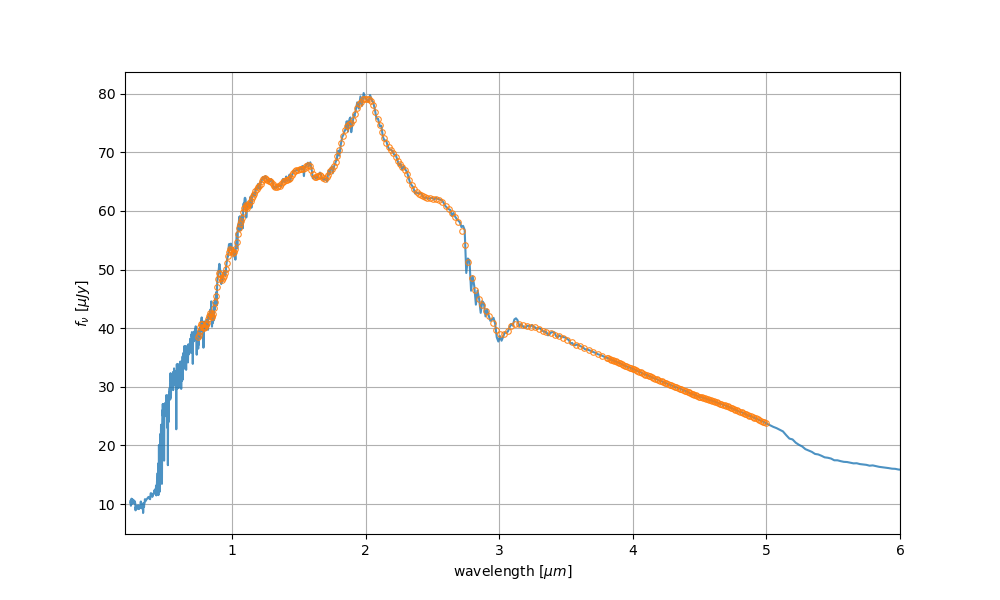

In [10]:
plt.close()
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(lbs * (1+myparams['zred']), flux, linewidth=1.5, alpha=0.8)  # you have to shift it to obs-frame
ax.plot(lamb_obs, flux_conv, 'o', markersize=4, markerfacecolor='none', markeredgewidth=0.8, alpha=0.9)
ax.grid()

ax.set_xlabel(r'wavelength [$\mu m$]')
ax.set_ylabel(r'$f_{\nu}$ [$\mu Jy$]')
ax.set_xlim(0.2, 6.0)

To quickly generate lots of galaxies, or for MCMC code to quickly call this function,  
we just need to modify myparams and repeatly call `cpt.generate_spectra(myparams)`